# H3 hexgrid resolution effects on Local Moran's I

**Question we answer here**: why do LISA results change so dramatically as we increase the H3 hexgrid resolution, even when the underlying data is unchanged?

**Short answer**: the apparent "more spatial autocorrelation at higher resolution" is largely an *artefact* of how we resample the data, not a genuine signal. When `polyfill_resample` fragments each parent field polygon into many child hexes, each hex inherits the same value as its siblings. From `Moran_Local`'s point of view, those siblings look like independent observations of identical values clustered in space, and it dutifully reports them as a strong HH or LL cluster with extremely small p-values. This notebook quantifies and visualises that inflation, names the four mechanisms responsible for it, and gives a rule of thumb for choosing a sensible resolution.

**TL;DR**:
- Pick H3 resolution so that one hex covers roughly one parent field on average. For our 100-field, 0.1° × 0.1° demo tile that's res 7–8.
- Higher-cardinality indicators (many distinct values across the tile) tolerate aggregation better than low-cardinality ones (e.g. `freq_*` with only 2–3 distinct values).
- The diagnostic `st.warning` added in PR #5 fires when the resampled indicator has `< 5` unique values — that's the *symptom* you should worry about, not the resolution number per se.

### Glossary — what we mean by "cardinality"

Throughout this notebook we describe each indicator by **`n_unique`** — the number of distinct values it takes across the tile. We avoid the loose terms *"continuous"* / *"categorical"* / *"discrete"* because the indicator dtype (`float`) doesn't tell you anything about the empirical distribution. We classify by `n_unique` instead:

| `n_unique` on the tile | label used here | implication for Moran's I |
|---|---|---|
| 2 | binary-valued | `(x_i - mean)` takes 2 values; Moran's I reduces to a binary spatial-separation test |
| 3–4 | low-cardinality | LISA still informative but loses fine-grained ordering |
| 5–20 | mid-cardinality | acceptable for LISA, warning *won't* fire |
| > 20 | high-cardinality | LISA behaves as in textbook examples |

This is the framing PR #5 codifies: the warning fires at `n_unique < 5`. The relevant property is *the empirical distribution after resampling*, not the conceptual nature of the variable.

## Setup

We import the same modules the Streamlit app uses, so this notebook reproduces what the user sees in the UI when they tick the *Use H3 Hexgrid* toggle and run autocorrelation. To run this notebook inside the project's Docker container you need a Jupyter kernel exposed by the container — `requirements.txt` already pins `jupyterlab` and `ipykernel`, but the default `CMD` only starts Streamlit. Either `docker exec` to launch JupyterLab on a new port, or add a sidecar service to `docker-compose.yml` (see the README/PR for the snippet).

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from esda import Moran, Moran_Local

# Make the project package importable when this notebook lives under notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from app.data_synthesis.field_loader import FieldLoader
from app.spatial_autocorrelation.geo_utils import compute_weights, geopandas_to_h3

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

LISA_COLORS = {
    "HH": "#FF0000",
    "HL": "#FFD580",
    "LH": "#87CEEB",
    "LL": "#0074D9",
    "ns": "#D3D3D3",
}
LABEL_ORDER = ["HH", "HL", "LH", "LL", "ns"]

In [2]:
# `max_fields` is a defensive cap to bound memory on big tiles, NOT a target.
# The Streamlit sidebar slider in app/main.py defaults to 2000; here we use the same default.
# The demo tile only contains 100 features, so `len(gdf)` will always be 100 regardless of the cap.
MAX_FIELDS = 2000
fl = FieldLoader(base_dir=str(PROJECT_ROOT / "data"))
gdf = fl.load_fields_with_properties("_demo_crop_fd_test_tile_v1.geojson", max_fields=MAX_FIELDS)
print(f"fields loaded: {len(gdf)} (max_fields cap = {MAX_FIELDS})")
print(f"crop_pct_2022: mean={gdf['crop_pct_2022'].mean():.2f}, std={gdf['crop_pct_2022'].std():.2f}, n_unique={gdf['crop_pct_2022'].nunique()}")
print(f"freq_corn: mean={gdf['freq_corn'].mean():.4f}, std={gdf['freq_corn'].std():.4f}, n_unique={gdf['freq_corn'].nunique()}, n_nan={gdf['freq_corn'].isna().sum()}")

fields loaded: 100 (max_fields cap = 2000)
crop_pct_2022: mean=61.12, std=16.29, n_unique=3
freq_corn: mean=0.5683, std=0.2107, n_unique=2, n_nan=16


Two indicators on purpose:

Two indicators on purpose, both with low empirical cardinality on this synthetic tile:

- **`crop_pct_2022`** — share of each field covered by its dominant crop in 2022. 100 valid fields (no NaN), std ≈ 16 pp. **`n_unique = 3`** on this tile (35, 60, 92). Low-cardinality.
- **`freq_corn`** — proportion of years 2008–2022 in which corn was the field's dominant crop. **`n_unique = 2`** (0.467 alternating, 1.0 monoculture), with 16 NaN fields where corn never dominated. Binary-valued.

Note: this is the synthetic test tile, intentionally crafted from 3 cropping regimes so the test surface is small and the spatial pattern is easy to validate. In a *real-world* tile `crop_pct_*` would have far more unique values (potentially one per field), while `freq_*` derived from CDL year-counts would still be highly discrete (only `k+1` possible values for a `k`-year window). The discreteness differential between the two indicators is therefore intrinsic, not a quirk of this tile.

Both describe the same underlying agronomy (corn-monoculture cluster top-right, soybean cluster bottom-left, alternating middle band). What differs is the empirical distribution — and as we'll see, that's what dominates the LISA outcome at high resolution.

## Sweep: field level vs H3 resolutions 6–10

For each (indicator, resolution) we record:

- `n_units`: the number of geometries the LISA test sees (fields, or hexes).
- `n_unique`: distinct values of the indicator across those geometries.
- `replication`: `n_units / n_fields` — how many "copies" of each field's value the LISA test ends up seeing on average. `1.0` is the field baseline; > 1 means we're inflating the sample by repeating the same value across multiple hexes.
- `moran_I`: the global Moran's I statistic (closer to 1 ⇒ more spatial autocorrelation, 0 ⇒ none, < 0 ⇒ dispersion).
- `p_sim`: pseudo p-value from conditional randomisation (999 permutations, the `esda` default).
- `lisa_labels`: the LISA quadrant labels (HH/HL/LH/LL) at `p < 0.05`, with NaN rows mapped to `ns`.

In [3]:
def label_lisa(values: pd.Series, w, p_value: float = 0.05) -> pd.Series:
    """Return LISA labels using the same NaN-safe path as the production code.
    
    Mirrors `app.spatial_autocorrelation.moran.add_local_autocorrelation_labels`:
    rows with NaN in the indicator never enter Moran_Local (which would otherwise
    propagate NaN through Is/z_sim and collapse `q` to 3, mislabelling everything
    as LL).
    """
    labels = pd.Series(["ns"] * len(values), index=values.index)
    valid = values.dropna()
    if len(valid) < 3:
        return labels
    lisa = Moran_Local(valid.values, w)
    sig = lisa.p_sim < p_value
    valid_labels = pd.Series(["ns"] * len(valid), index=valid.index)
    valid_labels[sig & (lisa.q == 1)] = "HH"
    valid_labels[sig & (lisa.q == 2)] = "LH"
    valid_labels[sig & (lisa.q == 3)] = "LL"
    valid_labels[sig & (lisa.q == 4)] = "HL"
    labels.loc[valid.index] = valid_labels
    return labels


def run_one(gdf_unit: "gpd.GeoDataFrame", indicator: str) -> dict:
    """Run global Moran + LISA labels on a (possibly H3-resampled) GeoDataFrame."""
    valid_mask = gdf_unit[indicator].notna()
    valid = gdf_unit[valid_mask]
    if len(valid) < 3:
        return None
    w = compute_weights(valid, weights="queen")
    m = Moran(valid[indicator].values, w)
    labels = label_lisa(gdf_unit[indicator], w)
    counts = labels.value_counts().reindex(LABEL_ORDER, fill_value=0).to_dict()
    return {
        "indicator": indicator,
        "n_units": len(gdf_unit),
        "n_valid": int(valid_mask.sum()),
        "n_unique": int(valid[indicator].nunique()),
        "std": float(valid[indicator].std()),
        "moran_I": float(m.I),
        "p_sim": float(m.p_sim),
        **{f"label_{k}": v for k, v in counts.items()},
        "_labels": labels,
        "_geom": gdf_unit.geometry,
    }


results = []
indicators = ["crop_pct_2022", "freq_corn"]

for ind in indicators:
    field_res = run_one(gdf, ind)
    field_res["resolution"] = "field"
    results.append(field_res)
    for res in [6, 7, 8, 9]:
        gh = geopandas_to_h3(gdf, resolution=res)
        r = run_one(gh, ind)
        if r is None:
            continue
        r["resolution"] = res
        results.append(r)

df = pd.DataFrame(results)
df["replication"] = df["n_units"] / len(gdf)
summary_cols = [
    "indicator", "resolution", "n_units", "n_valid", "replication",
    "n_unique", "std", "moran_I", "p_sim",
    "label_HH", "label_HL", "label_LH", "label_LL", "label_ns",
]
df[summary_cols]

,indicator,resolution,n_units,n_valid,replication,n_unique,std,moran_I,p_sim,label_HH,label_HL,label_LH,label_LL,label_ns
0,crop_pct_2022,field,100,100,1.00,3,16.286128,0.814702,0.001,12,0,4,16,68
1,crop_pct_2022,6,3,3,0.03,2,18.475209,-0.500000,0.001,0,1,2,0,0
2,crop_pct_2022,7,20,20,0.20,3,17.517735,0.598886,0.001,4,0,0,3,13
3,crop_pct_2022,8,131,131,1.31,3,16.119307,0.845684,0.001,21,0,4,22,84
4,crop_pct_2022,9,930,930,9.30,3,16.255574,0.942619,0.001,149,0,7,165,609
5,freq_corn,field,100,84,1.00,2,0.210672,0.773529,0.001,12,1,2,1,84
6,freq_corn,6,3,3,0.03,2,0.307901,-0.500000,0.001,0,1,2,0,0
7,freq_corn,7,20,17,0.20,2,0.233179,0.613462,0.001,3,0,1,0,16
8,freq_corn,8,131,111,1.31,2,0.209819,0.808201,0.001,16,0,3,54,58
9,freq_corn,9,930,781,9.30,2,0.210213,0.927842,0.001,142,0,7,0,781


## Mechanism 1 — Sample-size inflation, NOT new spatial structure

Look at `n_units` vs `n_valid`. The 100 parent fields turn into 131 hexes at res 8 and 930 hexes at res 9 — a 9× inflation. But the underlying *information* is unchanged; we just rasterised the same 100 polygons more finely.

Compare global Moran's I across resolutions for the same indicator. Field level → res 8 → res 9 climbs from ~0.81 → ~0.85 → ~0.94. That increase isn't "more autocorrelation appearing as we look more closely" — it's a structural artefact:

- The pseudo p-value of `Moran_Local` is computed against a permutation distribution whose variance scales as `1/N`. Larger `N` ⇒ tighter null ⇒ many more cells cross `p < 0.05` for the same true effect size.
- Each parent field that produces 10 hexes contributes 10 "observations" with the **same value** to Moran's numerator. The sum-of-products `Σ z_i · z_j` over all `(i, j)` pairs grows roughly with the number of pseudo-replicates, not the underlying spatial signal.

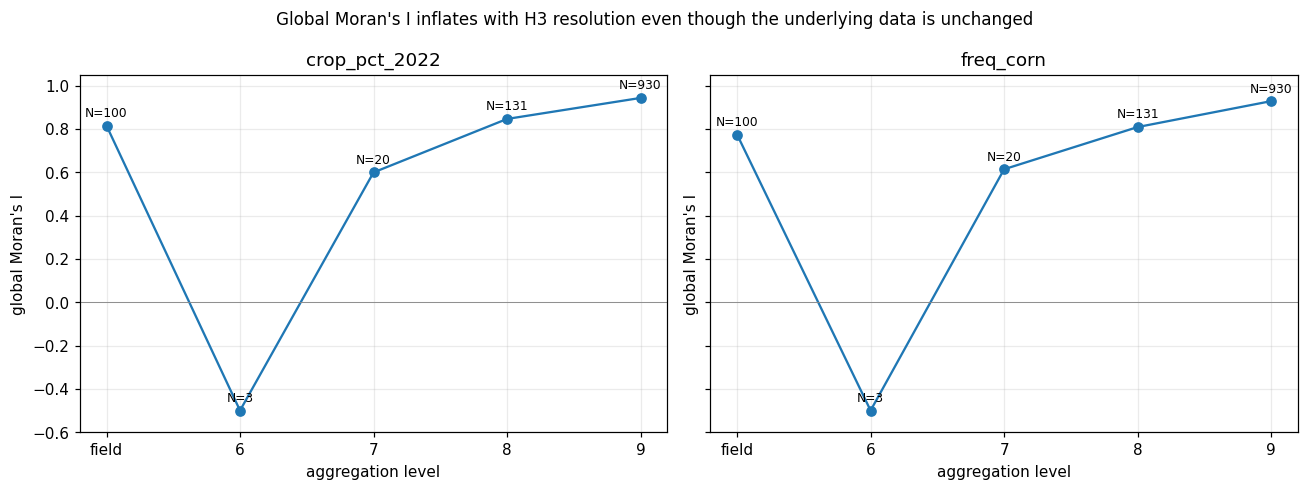

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, ind in zip(axes, indicators):
    sub = df[df["indicator"] == ind].copy()
    xs = [str(r) for r in sub["resolution"]]
    ax.plot(xs, sub["moran_I"], "o-", color="#1f77b4", label="global Moran's I")
    ax.set_title(ind)
    ax.set_xlabel("aggregation level")
    ax.set_ylabel("global Moran's I")
    ax.set_ylim(-0.6, 1.05)
    ax.axhline(0, color="#888", lw=0.6)
    ax.grid(True, alpha=0.25)
    for x, y, n in zip(xs, sub["moran_I"], sub["n_units"]):
        ax.annotate(f"N={n}", (x, y), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
fig.suptitle("Global Moran's I inflates with H3 resolution even though the underlying data is unchanged", fontsize=11)
fig.tight_layout()

Note `crop_pct_2022` at res 6 in particular — only 3 hexes exist at that resolution, so the test reports `I = -0.5` (which simply means "with N=3 each cell has 2 different neighbours, no real signal"). This isn't a problem with the test or our data; it's just that res 6 is too coarse for a 0.1° tile.

## Mechanism 2 — Pseudo-replicates from `polyfill_resample`

`geopandas_to_h3` calls `gdf.h3.polyfill_resample(resolution=res)` from `h3pandas`. That method covers each input polygon with H3 cells and **assigns each child hex the value of its parent polygon** (no aggregation, no smoothing). Plot how much `n_units` exceeds `n_fields`:

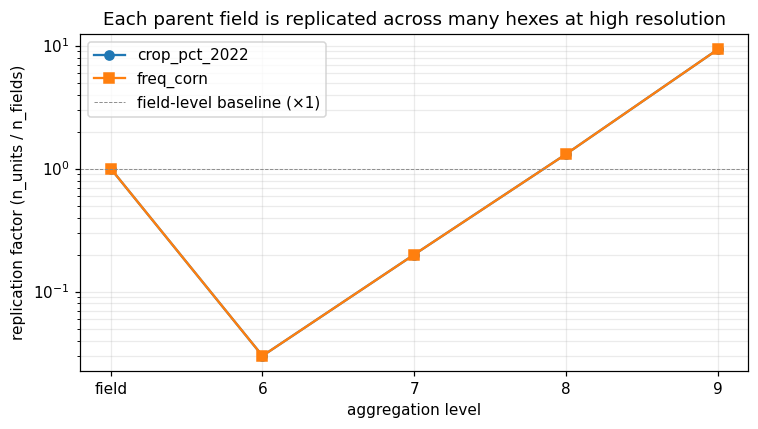

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for ind, marker in zip(indicators, ["o", "s"]):
    sub = df[df["indicator"] == ind].copy()
    xs = [str(r) for r in sub["resolution"]]
    ax.plot(xs, sub["replication"], marker=marker, label=ind)
ax.axhline(1.0, color="#888", lw=0.6, ls="--", label="field-level baseline (×1)")
ax.set_yscale("log")
ax.set_xlabel("aggregation level")
ax.set_ylabel("replication factor (n_units / n_fields)")
ax.set_title("Each parent field is replicated across many hexes at high resolution")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()

At res 9 each parent field becomes ≈9.3 hexes. None of them carry information beyond what the original field already encoded. Moran's I sees them as independent observations.

## Mechanism 3 — The queen contiguity neighbourhood changes meaning

At field level, the queen weights matrix connects each field to its ≈8 colliding neighbours — a meaningful agronomic neighbourhood. At hex level, queen connects each hex to its 6 surrounding hexes, but most of those neighbours are siblings inside the **same** parent field. So `z_i ≈ z_j` by construction (same value, copied), the local autocorrelation lights up trivially, and the LISA quadrant chains to LL or HH depending on whether the field is below or above the global mean.

Look at how the LISA label distribution shifts with resolution:

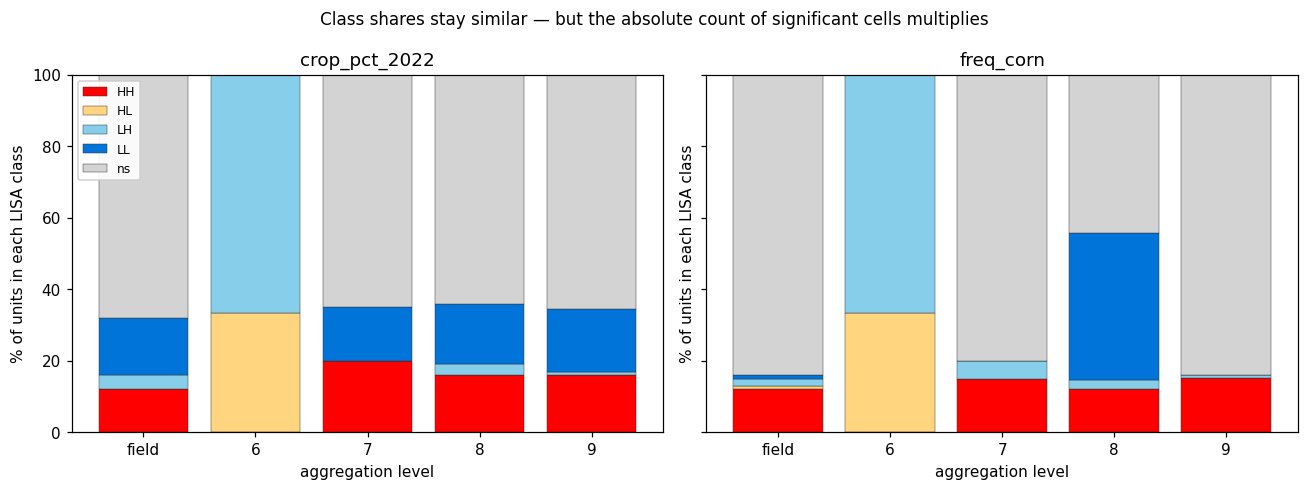

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, ind in zip(axes, indicators):
    sub = df[df["indicator"] == ind].copy()
    xs = [str(r) for r in sub["resolution"]]
    pct = sub[[f"label_{k}" for k in LABEL_ORDER]].values.astype(float)
    pct = pct / pct.sum(axis=1, keepdims=True) * 100
    bottom = np.zeros(len(xs))
    for i, k in enumerate(LABEL_ORDER):
        ax.bar(xs, pct[:, i], bottom=bottom, color=LISA_COLORS[k],
               edgecolor="#333", linewidth=0.3, label=k)
        bottom += pct[:, i]
    ax.set_title(ind)
    ax.set_xlabel("aggregation level")
    ax.set_ylabel("% of units in each LISA class")
axes[0].legend(loc="upper left", framealpha=0.9, fontsize=8)
fig.suptitle("Class shares stay similar — but the absolute count of significant cells multiplies", fontsize=11)
fig.tight_layout()

Two related observations from the bar chart:

- The *fraction* of significant cells doesn't grow much (≈30% for `crop_pct_2022` at every level). This is intuitive: roughly the same proportion of the tile sits in the strong corn or soybean clusters regardless of how finely we slice it.
- The *absolute count* of significant cells multiplies enormously: 12 HH fields at field level become 149 HH hexes at res 9 (the table above). This is the inflation users see when they switch the H3 toggle on — "so many more red hexes!" — and it is mechanical, not statistical.

Note also that for `freq_corn` only HH appears at high resolution (LL = 0). That is because the 16 fields with `freq_corn = NaN` are dropped before LISA runs; the remaining 0.467 cluster is *below* the (resampled) mean but isn't dense enough to flip its hexes' pseudo p-value below 0.05. With `crop_pct_2022` we keep all 100 fields, so both the high (corn = 92%) and low (soybean = 35%) clusters show up.

## Mechanism 4 — Distributional collapse for low-cardinality indicators

Different indicators have different empirical cardinality. `freq_corn` has `n_unique = 2` on this tile (0.467 and 1.0, plus NaN); `crop_pct_2022` has `n_unique = 3` (35, 60, 92). After `polyfill_resample` cardinality doesn't recover — the hexes inherit the same handful of values, just replicated. With `n_unique = 2`, Moran's I degenerates to a binary spatial-separation test (corn vs no-corn); with `n_unique = 3` it's a 3-class separation. In both cases, any region with a single dominant value will trivially register as a strong cluster. **Both indicators trip PR #5's `n_unique < 5` warning on this tile** — the visualisation below confirms it.

This is the case PR #5's `st.warning` is designed to flag (`n_unique < 5`). Plot `n_unique` against resolution:

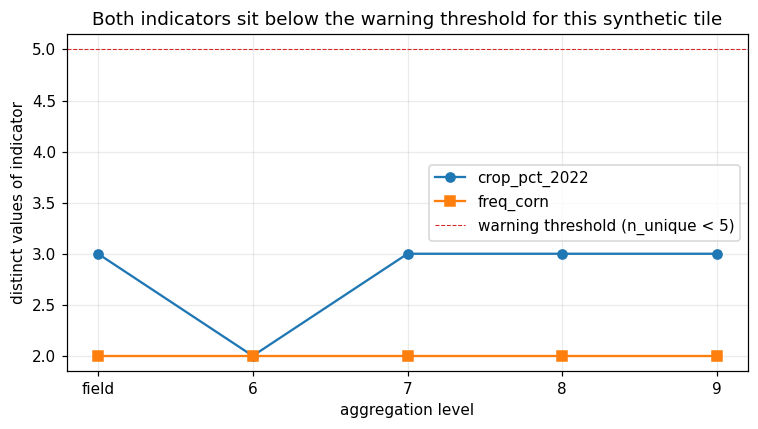

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for ind, marker in zip(indicators, ["o", "s"]):
    sub = df[df["indicator"] == ind].copy()
    xs = [str(r) for r in sub["resolution"]]
    ax.plot(xs, sub["n_unique"], marker=marker, label=ind)
ax.axhline(5, color="#d62728", lw=0.7, ls="--", label="warning threshold (n_unique < 5)")
ax.set_xlabel("aggregation level")
ax.set_ylabel("distinct values of indicator")
ax.set_title("Both indicators sit below the warning threshold for this synthetic tile")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()

## Side-by-side maps: how the same data renders across resolutions

The clearest visualisation is to plot `crop_pct_2022` LISA labels at field level vs at res 7, 8, 9 on the same axes. The HH cluster's *real* size doesn't change between panels — but the count of cells labelled HH does.

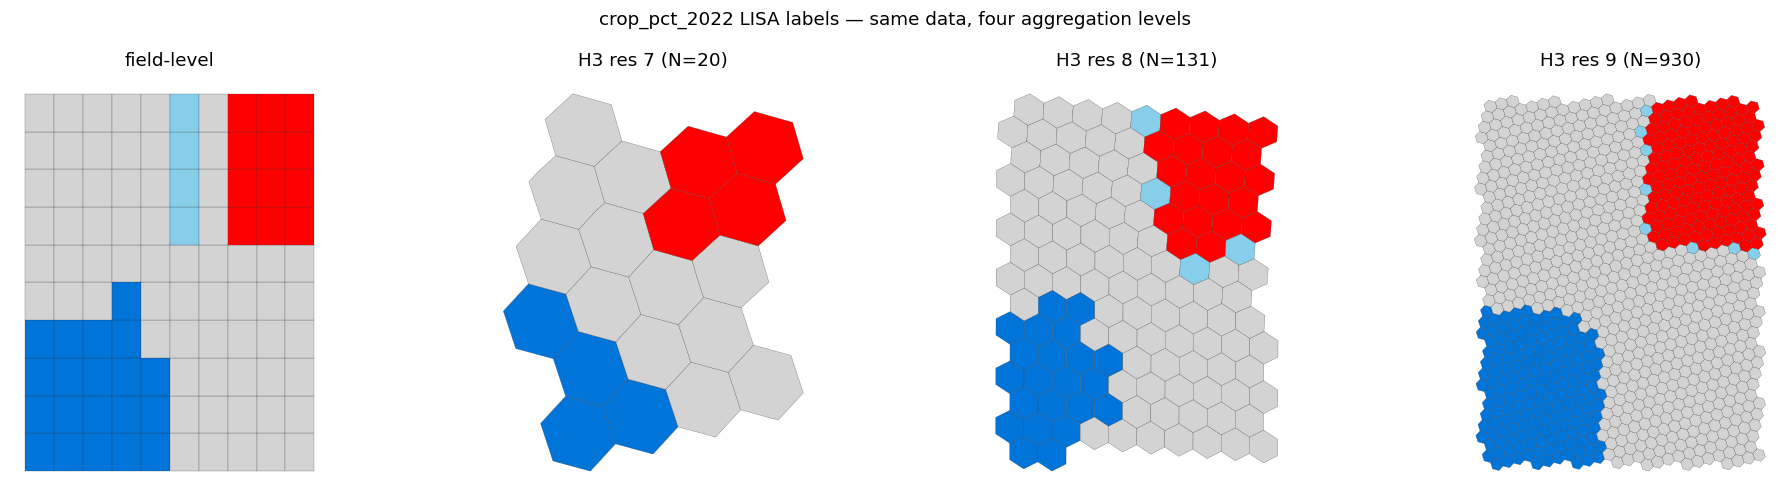

In [8]:
panels = [
    ("field-level", gdf, label_lisa(gdf["crop_pct_2022"], compute_weights(gdf, "queen"))),
]
for res in [7, 8, 9]:
    gh = geopandas_to_h3(gdf, resolution=res)
    valid = gh[gh["crop_pct_2022"].notna()]
    w = compute_weights(valid, "queen")
    panels.append((f"H3 res {res} (N={len(gh)})", gh, label_lisa(gh["crop_pct_2022"], w)))

fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
for ax, (title, geom, labels) in zip(axes, panels):
    plot = geom.copy()
    plot["_label"] = labels
    plot["_color"] = plot["_label"].map(LISA_COLORS)
    plot.plot(color=plot["_color"], ax=ax, edgecolor="#333", linewidth=0.15)
    ax.set_title(title)
    ax.set_axis_off()
fig.suptitle("crop_pct_2022 LISA labels — same data, four aggregation levels", fontsize=12)
fig.tight_layout()

Reading right-to-left: at res 9 there is a *vivid* solid-red HH region and a *vivid* solid-blue LL region — that's not new structure appearing as we look more closely; it's the same field-level pattern dyed in across all the child hexes. The grey 'transition' zone the field map shows clearly disappears, replaced by sharp deterministic edges between HH and LL.

## Operational guidance

1. **Match resolution to mean field size.** As a first cut, pick the lowest resolution where each field still resolves to *roughly one* hex (≈ replication factor 1.0–1.5). For our 0.1° / ≈9 km² tile, that's res 7–8.
2. **Watch the diagnostic warning.** PR #5 surfaces `n_unique < 5` automatically. If the warning fires, the LISA result for that combination of indicator + resolution should be treated as illustrative, not statistical.
3. **Prefer high-cardinality indicators for high-resolution analysis.** Indicators that take many distinct values across the tile (`area`, `perimeter`, or real-world `crop_pct_*` measured per-field) tolerate a higher replication factor than low-cardinality ones (`freq_*`, or any indicator that collapses to 2–4 unique values after resampling).
4. **If you specifically need hex-level outputs, aggregate *up* to hexes from sub-field observations — don't fragment fields *down* into hexes**. The current pipeline does the latter (`polyfill_resample`), which is appropriate for visualisation/zonification but not for inferential statistics. A future enhancement could compute `Moran_Local` on the field geometry while only *rendering* the result on the hex layer.

## Appendix — one-line summary of the four mechanisms

| # | Mechanism | Symptom |
|---|---|---|
| 1 | Pseudo p-value scales with `1/N` | More cells cross `p < 0.05` as N grows |
| 2 | `polyfill_resample` replicates parent value into all child hexes | Replication factor » 1 |
| 3 | Queen neighbours are mostly siblings of the same parent | Sharp HH/LL borders that match parcel geometry |
| 4 | Categorical-ish indicators collapse to 2–3 unique values | `n_unique < 5` warning fires |